# Epistasis Model Comparison: Raw vs Latent Phenotypes (BA4)

This notebook trains polynomial linear regression models (orders 1–4) with 8-fold cross-validation across the raw and latent (nonlinear-transformed) phenotype datasets. It compares:

1) Inference restricted to genotypes with `pos4 == 1` vs using all data, for each phenotype dataset (raw and each transform);
2) For each subset type (pos4==1 or all data), comparing raw vs each latent transform across model orders.

Outputs include summary tables and plots of mean and standard deviation of train/test R².

In [ ]:
# Setup and Data Loading
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import statsmodels.api as sm

# Directory configuration
RAW_DIR     = '../../../../datasets_for_inference'
LATENT_BASE = '../../../../global_epistasis_inference/ba4'
OUTPUT_DIR  = 'CV_summaries'

# Configuration
ANTIGEN        = 'ba4'
INFILE         = 'ba4_epistasis.csv'
GENO_COL       = 'geno'
PHENO_COL      = 'ba4_log10Kd_mean'
POS4_COL       = 'pos4'
POS4_MUT_INDEX = 3  # zero-based mutation index for pos4 (S75G, S56G in Tharp et al, 2026)
N_FOLDS        = 8
MAX_ORDER      = 4
RANDOM_STATE   = 42

# Switches: subset & encoding
ENCODING              = 'stat'   # 'biochem' => 0/1 (reference-based)  |  'stat' => -1/+1 (reference-free)
NONLINEAR_MODEL       = 'hill'  # link-function name only (e.g. 'hill', 'logistic') — matches {ANTIGEN}_epistasis_linearized_{NONLINEAR_MODEL}_v*_{ENCODING}.csv
PIN_VALUE             = 7.0
ALPHA                 = 0.05
COUNT_INTERCEPT_AS_TERM = False  # intercept is not a mutational term; set True to count it anyway

# Derived: latent subdirectory depends on encoding
_enc_subdir = 'reference-based' if ENCODING == 'biochem' else 'reference-free'
LATENT_DIR  = os.path.join(LATENT_BASE, _enc_subdir)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Config: ANTIGEN={ANTIGEN}, ENCODING={ENCODING}")
print(f"  RAW_DIR    : {RAW_DIR}")
print(f"  LATENT_DIR : {LATENT_DIR}")
print(f"  OUTPUT_DIR : {OUTPUT_DIR}")
print(f"  NONLINEAR_MODEL: {NONLINEAR_MODEL}")

# Load raw dataset
raw_df = pd.read_csv(os.path.join(RAW_DIR, INFILE))
raw_df[GENO_COL] = raw_df[GENO_COL].astype(str).str.strip().str.replace(r"[^01]", "", regex=True)
raw_df = raw_df.loc[raw_df[GENO_COL].str.len() > 0].copy()
L = int(raw_df[GENO_COL].str.len().max())
raw_df[GENO_COL] = raw_df[GENO_COL].str.zfill(L)

if POS4_COL in raw_df.columns:
    raw_df[POS4_COL] = raw_df[POS4_COL].astype(int)
else:
    raise KeyError("Column 'pos4' not found in input CSV")
pinned_mask_all = (raw_df[PHENO_COL].to_numpy(dtype=float) == PIN_VALUE)

# Find latent transform CSVs
transform_pattern = os.path.join(LATENT_DIR, f"{ANTIGEN}_epistasis_linearized_{NONLINEAR_MODEL}_v*_{ENCODING}.csv")
transform_paths   = sorted(glob.glob(transform_pattern))
print(f"Found {len(transform_paths)} transform files in {LATENT_DIR}")

latent_sets = {}
for p in transform_paths:
    base = os.path.basename(p)
    stem = (base
             .replace(f"{ANTIGEN}_epistasis_linearized_", "")
             .replace(f"_{ENCODING}.csv", ""))  # e.g. "hill_v1"
    df_t = pd.read_csv(p)
    df_t[GENO_COL] = (df_t[GENO_COL].astype(str)
                      .str.strip()
                      .str.replace(r"[^01]", "", regex=True)
                      .str.zfill(L))
    df_m = raw_df[[GENO_COL, POS4_COL]].merge(df_t[[GENO_COL, PHENO_COL]], on=GENO_COL, how="left")
    latent_sets[stem] = df_m

print(f"Latent sets: {list(latent_sets.keys())}")
print(f"L={L}, rows={len(raw_df)}")


Config: ANTIGEN=ba4, ENCODING=stat
  RAW_DIR    : ../../../../datasets_for_inference
  LATENT_DIR : ../../../../global_epistasis_inference/ba4/reference-free
  OUTPUT_DIR : CV_summaries
  NONLINEAR_MODEL: hill
Found 2 transform files in ../../../../global_epistasis_inference/ba4/reference-free
Latent sets: ['hill_v1', 'hill_v2']
L=13, rows=7416


In [2]:
# Define Dataset Variants (raw vs latent transforms)
datasets = {'raw': raw_df[[GENO_COL, POS4_COL, PHENO_COL]].copy()}
datasets.update({f'latent_{k}': v[[GENO_COL, POS4_COL, PHENO_COL]].copy() for k, v in latent_sets.items()})
print(f"Datasets prepared: {list(datasets.keys())}")

# Helper: encode genotype series according to chosen encoding

def encode_geno_series(s):
    X = np.array([[int(c) for c in g] for g in s], dtype=int)
    if ENCODING == 'biochem':
        return X.astype(float)            # 0->0, 1->1 (biochem)
    elif ENCODING == 'stat':
        return (2 * X - 1).astype(float)  # 0->-1, 1->+1 (stat)
    else:
        raise ValueError(f"Unknown ENCODING: {ENCODING}")

# Helper: build polynomial feature matrix up to degree d (safe script style: interaction_only, include bias)
poly_cache = {}

def make_poly_features(X_base, degree):
    key = (X_base.shape, degree)
    if key not in poly_cache:
        pf = PolynomialFeatures(degree=degree, include_bias=True, interaction_only=True)
        poly_cache[key] = pf.fit(X_base)
    pf = poly_cache[key]
    return pf.transform(X_base)

# Plain linear regression with statsmodels for p-values
from sklearn.linear_model import LinearRegression


Datasets prepared: ['raw', 'latent_hill_v1', 'latent_hill_v2']


In [3]:
import statsmodels.api as sm

# Create Feature/Target Subsets
# "all": includes pinned
# "pos4_binders": pos4==1 AND strictly above PIN_VALUE (i.e., detectable binders only)
subset_defs = {
    "all":          lambda df: df,
    "pos4_binders": lambda df: df[(df[POS4_COL] == 1) & (df[PHENO_COL] > PIN_VALUE)],
}

# 8-Fold Cross-Validation
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

results      = []
fold_records = []

# Build the filtered dataset list for CV:
#   - raw            : both scopes ("all" and "pos4_binders")
#   - NONLINEAR_MODEL_v1 : scope "all" only
#   - NONLINEAR_MODEL_v2 : scope "pos4_binders" only
v1_key  = f"latent_{NONLINEAR_MODEL}_v1"
v2_key  = f"latent_{NONLINEAR_MODEL}_v2"
missing = [k for k in [v1_key, v2_key] if k not in datasets]
if missing:
    raise KeyError(
        f"NONLINEAR_MODEL datasets not found in datasets dict: {missing}. "
        f"Available: {list(datasets.keys())}"
    )

cv_entries = [
    ("raw",  datasets["raw"],  ["all", "pos4_binders"]),
    (v1_key, datasets[v1_key], ["all"]),
    (v2_key, datasets[v2_key], ["pos4_binders"]),
]

for ds_name, df0, allowed_scopes in cv_entries:
    X_base = encode_geno_series(df0[GENO_COL])
    y_all  = df0[PHENO_COL].to_numpy(dtype=float)

    for subset_name in allowed_scopes:
        df_sub = subset_defs[subset_name](df0)

        idx   = df_sub.index.to_numpy()
        X_sub = X_base[idx]
        y_sub = y_all[idx]

        finite_sub  = np.isfinite(y_sub)
        n_drop_sub  = int(np.sum(~finite_sub))
        if n_drop_sub > 0:
            print(f"NOTE: {ds_name}/{subset_name}: dropping {n_drop_sub} non-finite phenotypes before CV")
        X_sub = X_sub[finite_sub]
        y_sub = y_sub[finite_sub]

        if subset_name == "pos4_binders":
            feat_mask = np.ones(X_sub.shape[1], dtype=bool)
            feat_mask[POS4_MUT_INDEX] = False
            X_sub = X_sub[:, feat_mask]

        n_samples = len(y_sub)
        if n_samples < N_FOLDS:
            print(f"Skipping {ds_name}/{subset_name}: not enough samples ({n_samples} < {N_FOLDS})")
            continue

        for degree in range(1, MAX_ORDER + 1):
            r2_train_folds = []
            r2_test_folds  = []
            num_sig_folds  = []

            try:
                X_poly = make_poly_features(X_sub, degree)
            except Exception as e:
                print(f"{ds_name} | {subset_name} | deg={degree} | feature expansion failed: {e}")
                results.append({
                    "antigen": ANTIGEN, "phenotype_name": ds_name, "scope": subset_name,
                    "order": degree, "r2_train_mean": np.nan, "r2_train_std": np.nan,
                    "r2_test_mean": np.nan, "r2_test_std": np.nan,
                    "num_sig_mean": np.nan, "num_sig_std": np.nan, "n_samples": int(n_samples),
                })
                continue

            for fold_i, (train_idx, test_idx) in enumerate(kf.split(X_poly)):
                Xtr, Xte = X_poly[train_idx], X_poly[test_idx]
                ytr, yte = y_sub[train_idx],  y_sub[test_idx]

                tr_ok = np.isfinite(ytr); te_ok = np.isfinite(yte)
                Xtr2, ytr2 = Xtr[tr_ok], ytr[tr_ok]
                Xte2, yte2 = Xte[te_ok], yte[te_ok]

                if len(ytr2) < 5 or len(yte2) < 5:
                    r2_train_folds.append(np.nan); r2_test_folds.append(np.nan); num_sig_folds.append(np.nan)
                    fold_records.append({
                        "antigen": ANTIGEN, "phenotype_name": ds_name, "scope": subset_name,
                        "order": degree, "fold": fold_i, "r2_train": np.nan, "r2_test": np.nan,
                        "n_samples": int(n_samples), "n_train_used": int(len(ytr2)),
                        "n_test_used": int(len(yte2)), "n_params": np.nan,
                        "alpha_bonf": np.nan, "num_sig": np.nan,
                    })
                    continue

                try:
                    fit      = sm.OLS(ytr2, Xtr2).fit()
                    ytr_pred = fit.predict(Xtr2)
                    yte_pred = fit.predict(Xte2)
                    r2tr = r2_score(ytr2, ytr_pred)
                    r2te = r2_score(yte2, yte_pred)

                    pvals       = np.asarray(fit.pvalues)
                    n_params    = int(len(pvals))
                    alpha_bonf  = float(ALPHA / n_params)
                    num_sig     = int(np.sum(pvals < alpha_bonf)) if COUNT_INTERCEPT_AS_TERM                                   else int(np.sum(pvals[1:] < alpha_bonf))

                    r2_train_folds.append(float(r2tr))
                    r2_test_folds.append(float(r2te))
                    num_sig_folds.append(float(num_sig))
                    fold_records.append({
                        "antigen": ANTIGEN, "phenotype_name": ds_name, "scope": subset_name,
                        "order": degree, "fold": fold_i, "r2_train": float(r2tr), "r2_test": float(r2te),
                        "n_samples": int(n_samples), "n_train_used": int(len(ytr2)),
                        "n_test_used": int(len(yte2)), "n_params": int(n_params),
                        "alpha_bonf": float(alpha_bonf), "num_sig": int(num_sig),
                    })

                except Exception:
                    r2_train_folds.append(np.nan); r2_test_folds.append(np.nan); num_sig_folds.append(np.nan)
                    fold_records.append({
                        "antigen": ANTIGEN, "phenotype_name": ds_name, "scope": subset_name,
                        "order": degree, "fold": fold_i, "r2_train": np.nan, "r2_test": np.nan,
                        "n_samples": int(n_samples), "n_train_used": int(len(ytr2)),
                        "n_test_used": int(len(yte2)), "n_params": np.nan,
                        "alpha_bonf": np.nan, "num_sig": np.nan,
                    })

            train_vals = np.array(r2_train_folds, dtype=float)
            test_vals  = np.array(r2_test_folds,  dtype=float)
            sig_vals   = np.array(num_sig_folds,  dtype=float)

            row = {
                "antigen":       ANTIGEN,
                "phenotype_name": ds_name,
                "scope":          subset_name,
                "order":          degree,
                "r2_train_mean":  float(np.nanmean(train_vals)),
                "r2_train_std":   float(np.nanstd(train_vals, ddof=1)) if np.sum(np.isfinite(train_vals)) > 1 else np.nan,
                "r2_test_mean":   float(np.nanmean(test_vals)),
                "r2_test_std":    float(np.nanstd(test_vals,  ddof=1)) if np.sum(np.isfinite(test_vals))  > 1 else np.nan,
                "num_sig_mean":   float(np.nanmean(sig_vals)),
                "num_sig_std":    float(np.nanstd(sig_vals,   ddof=1)) if np.sum(np.isfinite(sig_vals))   > 1 else np.nan,
                "n_samples":      int(n_samples),
            }
            results.append(row)
            print(
                f"{ds_name} | {subset_name} | deg={degree} | "
                f"train R²={row['r2_train_mean']:.3f}±{row['r2_train_std'] if np.isfinite(row['r2_train_std']) else float('nan'):.3f} | "
                f"test R²={row['r2_test_mean']:.3f}±{row['r2_test_std'] if np.isfinite(row['r2_test_std']) else float('nan'):.3f} | "
                f"sig={row['num_sig_mean']:.1f}±{row['num_sig_std'] if np.isfinite(row['num_sig_std']) else float('nan'):.1f}"
            )

results_df = pd.DataFrame(results)
folds_df   = pd.DataFrame(fold_records)
print(f"Done CV: {len(results_df)} rows")


raw | all | deg=1 | train R²=0.798±0.002 | test R²=0.797±0.013 | sig=10.0±0.0
raw | all | deg=2 | train R²=0.835±0.002 | test R²=0.829±0.014 | sig=28.0±0.8
raw | all | deg=3 | train R²=0.881±0.002 | test R²=0.864±0.014 | sig=51.2±2.1
raw | all | deg=4 | train R²=0.915±0.001 | test R²=0.875±0.010 | sig=69.4±2.6
raw | pos4_binders | deg=1 | train R²=0.691±0.003 | test R²=0.688±0.022 | sig=9.0±0.0
raw | pos4_binders | deg=2 | train R²=0.760±0.003 | test R²=0.747±0.023 | sig=28.8±0.7
raw | pos4_binders | deg=3 | train R²=0.811±0.003 | test R²=0.767±0.022 | sig=35.8±2.0
raw | pos4_binders | deg=4 | train R²=0.852±0.002 | test R²=0.731±0.023 | sig=33.9±2.7
latent_hill_v1 | all | deg=1 | train R²=0.808±0.003 | test R²=0.806±0.019 | sig=10.0±0.0
latent_hill_v1 | all | deg=2 | train R²=0.836±0.003 | test R²=0.830±0.020 | sig=26.5±1.1
latent_hill_v1 | all | deg=3 | train R²=0.867±0.002 | test R²=0.849±0.019 | sig=44.0±2.3
latent_hill_v1 | all | deg=4 | train R²=0.896±0.002 | test R²=0.847±0.013 

CSVs saved to CV_summaries/


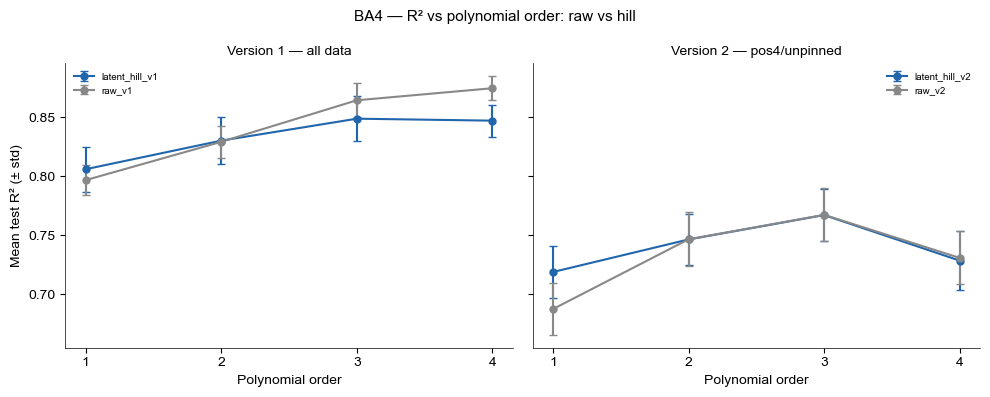

Saved: CV_summaries/ba4_r2_v1_v2_comparison.png


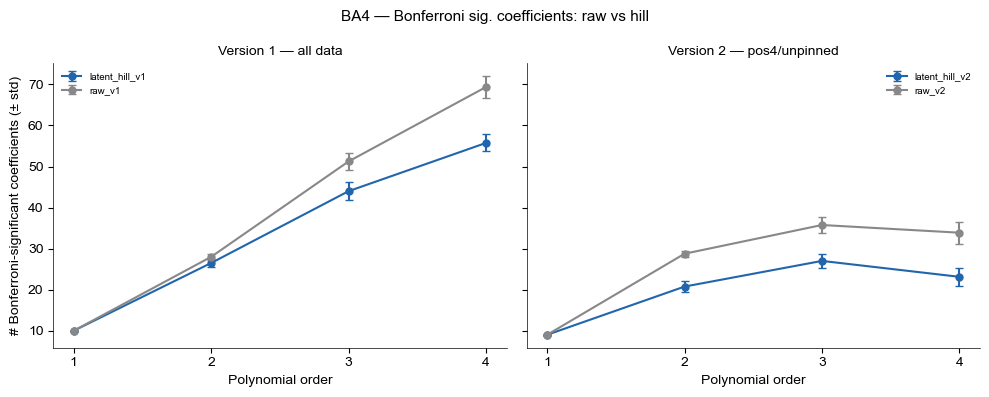

Saved: CV_summaries/ba4_bonferroni_sig_v1_v2_comparison.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Arial"

# Helper
def _safe_std(v):
    return float(v) if (v is not None and np.isfinite(float(v))) else np.nan

# Save CSVs
if results_df.empty:
    print("No results to summarize/plot.")
else:
    for ext, sep in [("tsv", "\t"), ("csv", ",")]:
        results_df.to_csv(os.path.join(OUTPUT_DIR, f"{ANTIGEN}_globalep_model_comparison.{ext}"), sep=sep, index=False)
    if not folds_df.empty:
        for ext, sep in [("tsv", "\t"), ("csv", ",")]:
            folds_df.to_csv(os.path.join(OUTPUT_DIR, f"{ANTIGEN}_globalep_model_folds.{ext}"), sep=sep, index=False)
    print(f"CSVs saved to {OUTPUT_DIR}/")

    # Build plot_df: assign version tag, one row per (phenotype, scope, order)
    def infer_version(name):
        if name in ("raw", "raw_v1", "raw_v2"): return name
        return "v1" if name.endswith("_v1") else ("v2" if name.endswith("_v2") else "other")

    plot_df = results_df[np.isfinite(results_df["r2_test_mean"])].copy()

    # Rename raw rows to raw_v1 / raw_v2 so they pair correctly with latent versions
    plot_df.loc[(plot_df["phenotype_name"] == "raw") & (plot_df["scope"] == "all"),          "phenotype_name"] = "raw_v1"
    plot_df.loc[(plot_df["phenotype_name"] == "raw") & (plot_df["scope"] == "pos4_binders"), "phenotype_name"] = "raw_v2"
    plot_df["version"] = plot_df["phenotype_name"].map(
        lambda n: "v1" if (n.endswith("_v1") or n == "raw_v1") else
                  ("v2" if (n.endswith("_v2") or n == "raw_v2") else "other")
    )

    # colour map: raw = grey, latent model = blue
    def _colour(name):
        return "#888888" if name.startswith("raw") else "#2166ac"

    orders = sorted(plot_df["order"].unique())

    # Figure 1: R² (mean ± std) — v1 left, v2 right
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    version_configs = [
        ("v1", "all data",         axes[0]),
        ("v2", "pos4/unpinned",    axes[1]),
    ]
    for vtag, scope_label, ax in version_configs:
        sub = plot_df[plot_df["version"] == vtag].copy()
        for ph in sorted(sub["phenotype_name"].unique()):
            s = sub[sub["phenotype_name"] == ph].sort_values("order")
            yerr = s["r2_test_std"].apply(_safe_std).to_numpy()
            ax.errorbar(
                s["order"], s["r2_test_mean"],
                yerr=yerr,
                fmt="-o", capsize=3, linewidth=1.5, markersize=5,
                color=_colour(ph),
                label=ph,
            )
        ax.set_title(f"Version {vtag[-1]} — {scope_label}", fontsize=10)
        ax.set_xlabel("Polynomial order")
        ax.set_xticks(orders)
        ax.spines[["top","right"]].set_visible(False)
        ax.spines["left"].set_linewidth(0.5)
        ax.spines["bottom"].set_linewidth(0.5)
        ax.tick_params(direction="out", which="both")
        ax.legend(fontsize=7, frameon=False)

    axes[0].set_ylabel("Mean test R² (± std)")
    fig.suptitle(f"{ANTIGEN.upper()} — R² vs polynomial order: raw vs {NONLINEAR_MODEL}", fontsize=11)
    plt.tight_layout()
    out_r2 = os.path.join(OUTPUT_DIR, f"{ANTIGEN}_r2_v1_v2_comparison.png")
    plt.savefig(out_r2, dpi=200, bbox_inches="tight")
    plt.savefig(out_r2.replace(".png", ".pdf"), bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_r2}")

    # Figure 2: # Bonferroni-significant coefficients — v1 left, v2 right
    df_sig = folds_df[np.isfinite(folds_df["num_sig"])].copy() if not folds_df.empty else pd.DataFrame()

    if df_sig.empty:
        print("No finite num_sig values; skipping Bonferroni plot.")
    else:
        # Rename raw rows to match plot_df convention
        df_sig.loc[(df_sig["phenotype_name"] == "raw") & (df_sig["scope"] == "all"),          "phenotype_name"] = "raw_v1"
        df_sig.loc[(df_sig["phenotype_name"] == "raw") & (df_sig["scope"] == "pos4_binders"), "phenotype_name"] = "raw_v2"
        df_sig["version"] = df_sig["phenotype_name"].map(
            lambda n: "v1" if (n.endswith("_v1") or n == "raw_v1") else
                      ("v2" if (n.endswith("_v2") or n == "raw_v2") else "other")
        )

        agg_sig = (
            df_sig
            .groupby(["phenotype_name", "version", "order"], as_index=False)
            .agg(num_sig_mean=("num_sig", "mean"), num_sig_std=("num_sig", "std"))
        )

        fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
        bonf_version_configs = [
            ("v1", "all data",      axes[0]),
            ("v2", "pos4/unpinned", axes[1]),
        ]
        for vtag, scope_label, ax in bonf_version_configs:
            sub = agg_sig[agg_sig["version"] == vtag].copy()
            for ph in sorted(sub["phenotype_name"].unique()):
                s = sub[sub["phenotype_name"] == ph].sort_values("order")
                yerr = s["num_sig_std"].apply(_safe_std).to_numpy()
                ax.errorbar(
                    s["order"], s["num_sig_mean"],
                    yerr=yerr,
                    fmt="-o", capsize=3, linewidth=1.5, markersize=5,
                    color=_colour(ph),
                    label=ph,
                )
            ax.set_title(f"Version {vtag[-1]} — {scope_label}", fontsize=10)
            ax.set_xlabel("Polynomial order")
            ax.set_xticks(orders)
            ax.spines[["top","right"]].set_visible(False)
            ax.spines["left"].set_linewidth(0.5)
            ax.spines["bottom"].set_linewidth(0.5)
            ax.tick_params(direction="out", which="both")
            ax.legend(fontsize=7, frameon=False)

        axes[0].set_ylabel("# Bonferroni-significant coefficients (± std)")
        fig.suptitle(f"{ANTIGEN.upper()} — Bonferroni sig. coefficients: raw vs {NONLINEAR_MODEL}", fontsize=11)
        plt.tight_layout()
        out_sig = os.path.join(OUTPUT_DIR, f"{ANTIGEN}_bonferroni_sig_v1_v2_comparison.png")
        plt.savefig(out_sig, dpi=200, bbox_inches="tight")
        plt.savefig(out_sig.replace(".png", ".pdf"), bbox_inches="tight")
        plt.show()
        print(f"Saved: {out_sig}")
